In [1]:
%load_ext autoreload

In [2]:
%autoreload 1

In [44]:
import os, sys
import numpy as np
from rich import print
from rich.pretty import pprint
from rich.progress import track
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
import hist
from hist import Hist
import mplhep as hep

parent_dir = os.path.dirname(os.path.abspath(""))
sys.path.append(parent_dir)

import cms_styles

%aimport plot_utils

In [4]:
mpl.rcParams.update({"figure.max_open_warning": 0})
hep.style.use("CMS")
np.set_printoptions(suppress=True)

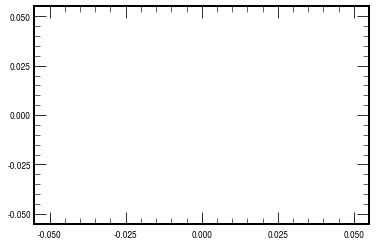

In [5]:
plt.plot()
hep.style.use(hep.style.CMS)
mpl.rcParams["figure.facecolor"] = "white"
plt.style.use(cms_styles.CMS_petroff_10)

## Load plots

In [29]:
plots = plot_utils.loader(tag="muon_kinematics_Apr2025")

## nMuon distribution

CR_prompt

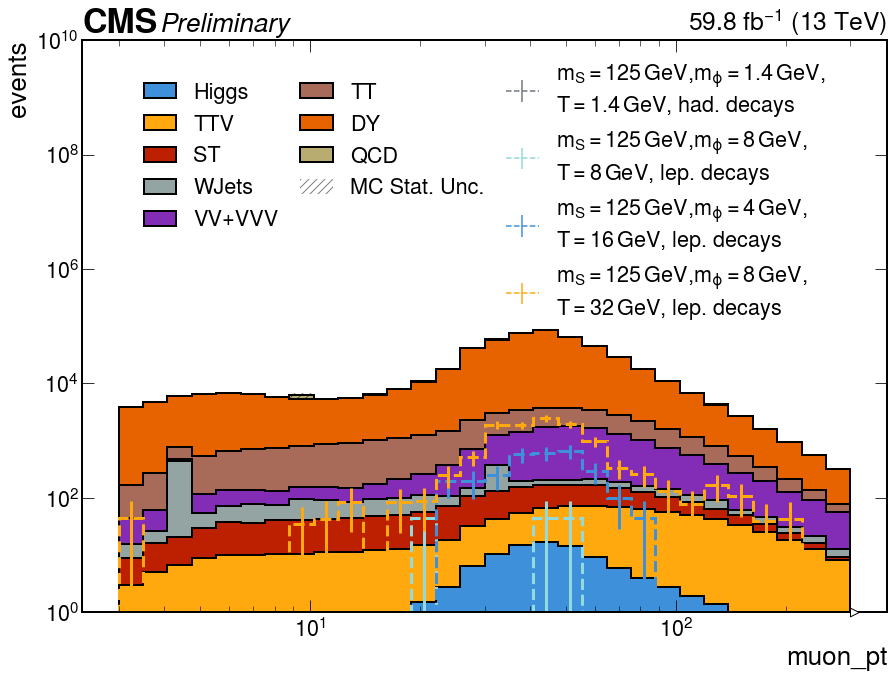

CR_cb

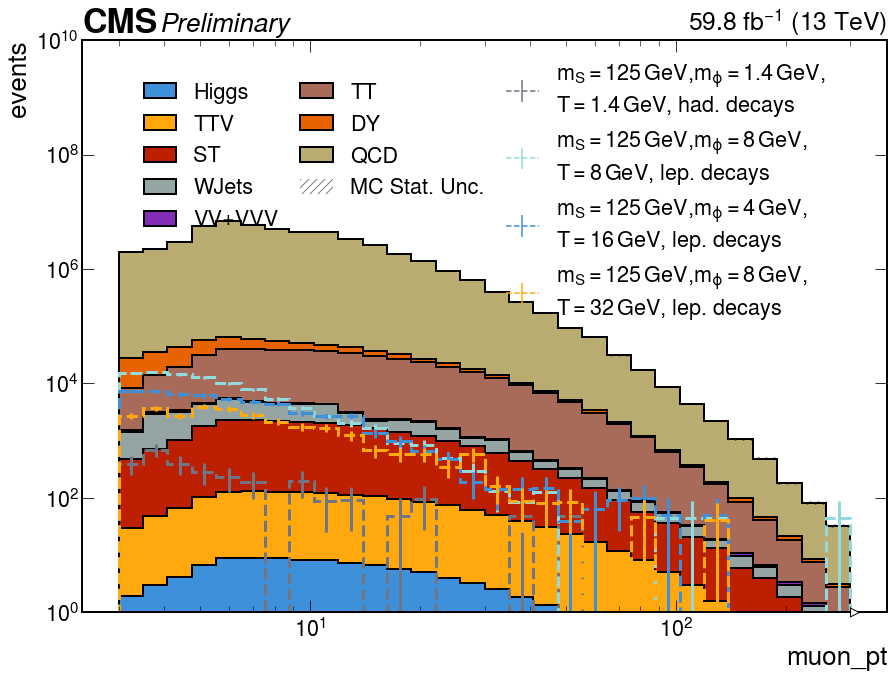

SR_high_temp_loose

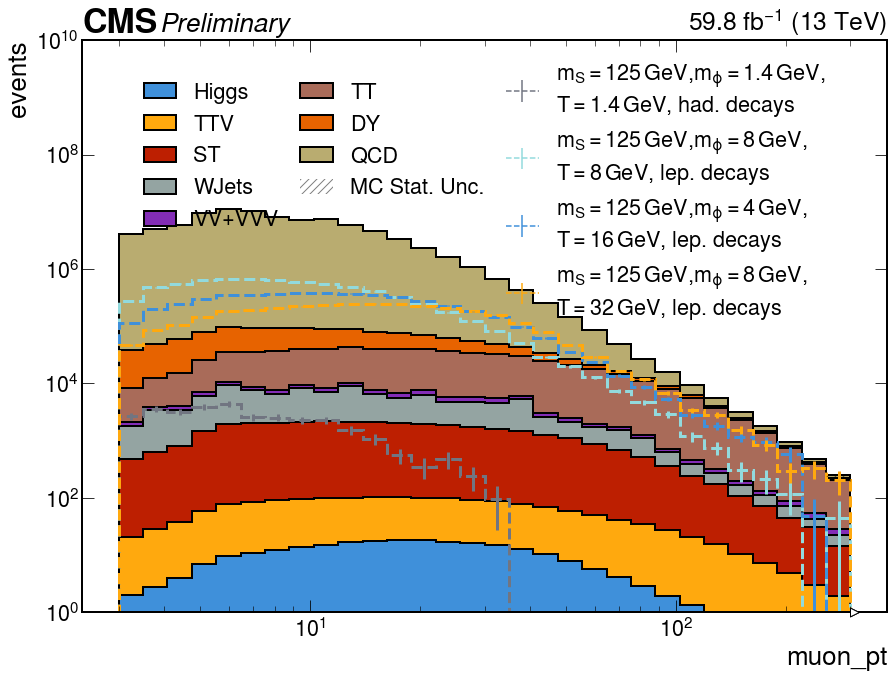

SR_high_temp_tight

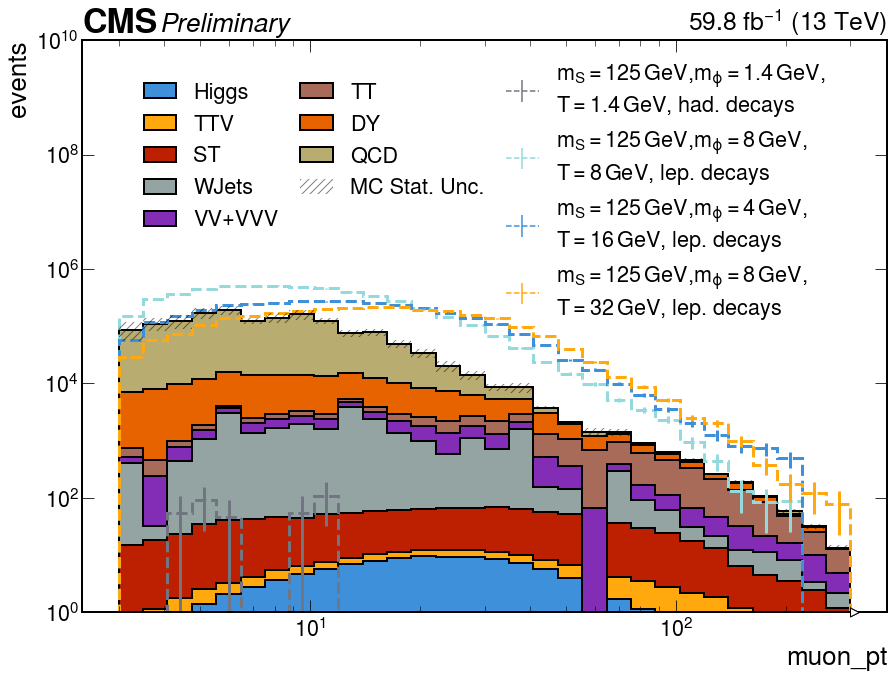

SR_low_temp_loose

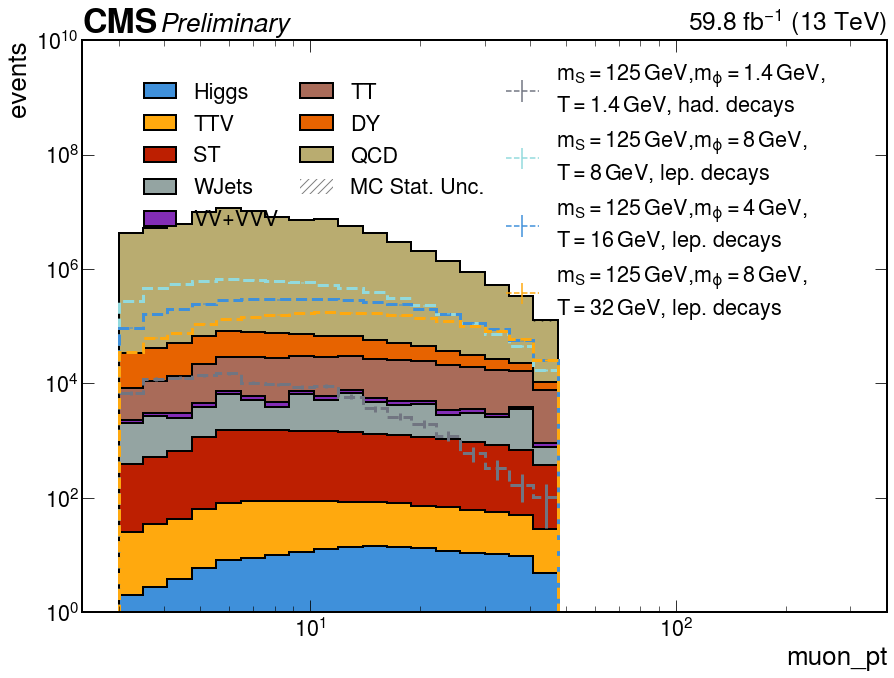

SR_low_temp_tight

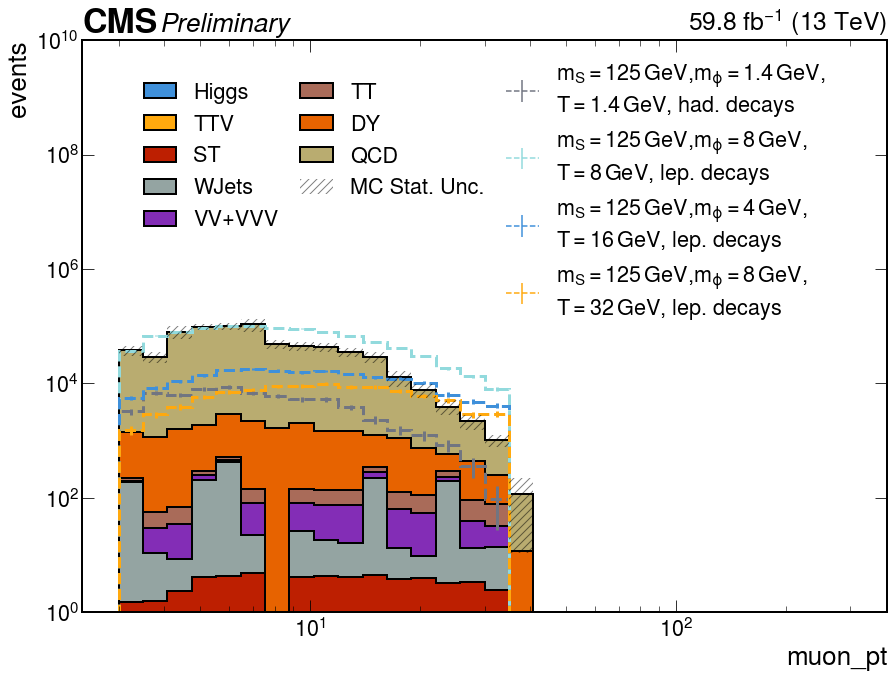

In [38]:
for region in [
    "CR_prompt",
    "CR_cb",
    "SR_high_temp_loose",
    "SR_high_temp_tight",
    "SR_low_temp_loose",
    "SR_low_temp_tight",
]:
    print(region)
    mc_processes = [
        ("Higgs_2018", "Higgs"),
        ("TTV_2018", "TTV"),
        ("ST_NLO_2018", "ST"),
        ("WJets_2018", "WJets"),
        ("VV+VVV_2018", "VV+VVV"),
        ("TT_powheg_2018", "TT"),
        ("DY_2018", "DY"),
        ("QCD_Pt_MuEnrichedPt5_2018", "QCD"),
    ]

    signal_processes = [
        "GluGluToSUEP_mS125.000_mPhi1.400_T1.400_modehadronic_13TeV_2018",
        "GluGluToSUEP_mS125.000_mPhi8.000_T8.000_modeleptonic_13TeV_2018",
        "GluGluToSUEP_mS125.000_mPhi4.000_T16.000_modeleptonic_13TeV_2018",
        "GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018",
    ]
    signal_labels = [
        r"$m_S=125\,$GeV,$m_\phi=1.4\,$GeV," + "\n" + r"$T=1.4\,$GeV, had. decays",
        r"$m_S=125\,$GeV,$m_\phi=8\,$GeV," + "\n" + r"$T=8\,$GeV, lep. decays",
        r"$m_S=125\,$GeV,$m_\phi=4\,$GeV," + "\n" + r"$T=16\,$GeV, lep. decays",
        r"$m_S=125\,$GeV,$m_\phi=8\,$GeV," + "\n" + r"$T=32\,$GeV, lep. decays",
    ]

    hists_mc = []
    hist_bkg_total = (
        plots["GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018"][
            region
        ][:, ::sum, ::sum]
        .copy()
        .reset()
    )

    for process, label in mc_processes:
        h_mc = plots[process][region][:, ::sum, ::sum]
        hists_mc.append(h_mc)
        hist_bkg_total += h_mc.copy()

    hists_signal = []
    for process in signal_processes:
        h_signal = plots[process][region][:, ::sum, ::sum]
        hists_signal.append(h_signal)

    fig, ax1 = plt.subplots(figsize=(13, 10))

    hep.histplot(
        hists_mc,
        yerr=[np.sqrt(h.variances()) for h in hists_mc],
        stack=True,
        label=[p[1] for p in mc_processes],
        histtype="fill",
        ec="black",
        lw=2,
        ax=ax1,
    )

    x_hatch = np.vstack(
        (hist_bkg_total.axes[0].edges[:-1], hist_bkg_total.axes[0].edges[1:])
    ).reshape((-1,), order="F")
    y_hatch1 = np.vstack((hist_bkg_total.values(), hist_bkg_total.values())).reshape(
        (-1,), order="F"
    )
    y_hatch1_unc = np.vstack(
        (np.sqrt(hist_bkg_total.variances()), np.sqrt(hist_bkg_total.variances()))
    ).reshape((-1,), order="F")
    ax1.fill_between(
        x=x_hatch,
        y1=y_hatch1 - y_hatch1_unc,  # type: ignore[assign]
        y2=y_hatch1 + y_hatch1_unc,  # type: ignore[assign]
        label="MC Stat. Unc.",
        step="pre",
        facecolor="none",
        edgecolor=(0, 0, 0, 0.5),
        linewidth=0,
        hatch="///",
        zorder=2,
    )
    hep.histplot(
        hists_signal,
        yerr=[np.sqrt(h.variances()) for h in hists_signal],
        label=[s for s in signal_labels],
        lw=3,
        ls="--",
        ax=ax1,
    )

    hep.cms.label(llabel="Preliminary", data=True, lumi=59.8, ax=ax1)

    plt.ylim(1e0, 1e10)
    plt.xscale("log")
    plt.yscale("log")
    plt.legend(ncol=3, loc="upper center", columnspacing=1)
    plt.ylabel("events")
    plt.tight_layout()
    plt.show()

### Do a CDF too

In [45]:
plots_cdfs = {}
for sample in track(plots):
    plots_cdfs[sample] = {}
    for plot in plots[sample]:
        plots_cdfs[sample][plot] = plots[sample][plot][:, ::sum, ::sum].copy().reset()
        for i in range(30):
            plots_cdfs[sample][plot][i] = (
                plots_cdfs[sample][plot][i - 1].value
                + plots[sample][plot][i, ::sum, ::sum].value,
                plots_cdfs[sample][plot][i - 1].variance
                + plots[sample][plot][i, ::sum, ::sum].variance,
            )

Working... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00
Working... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00

CR_prompt

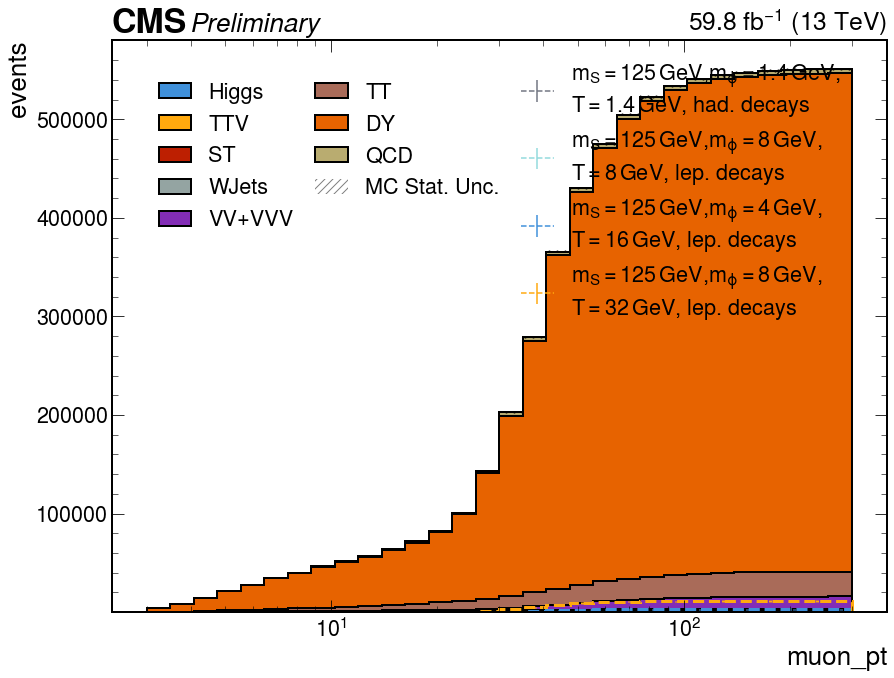

CR_cb

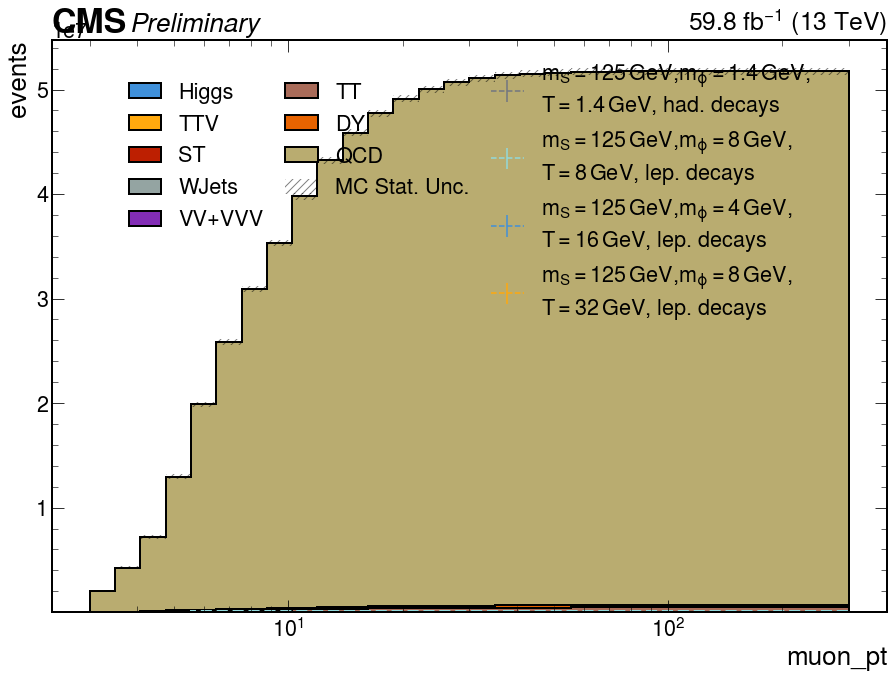

SR_high_temp_loose

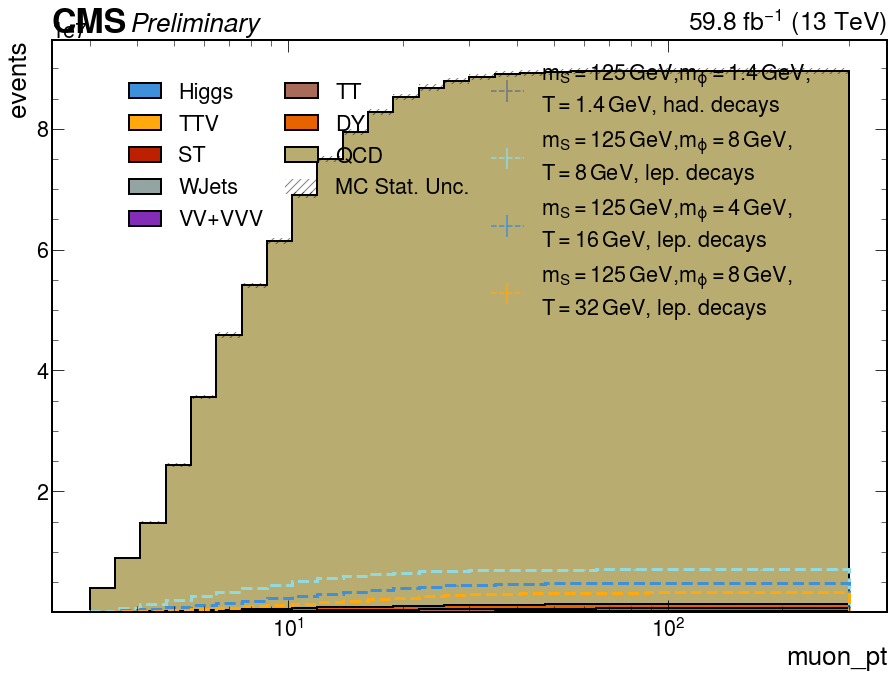

SR_high_temp_tight

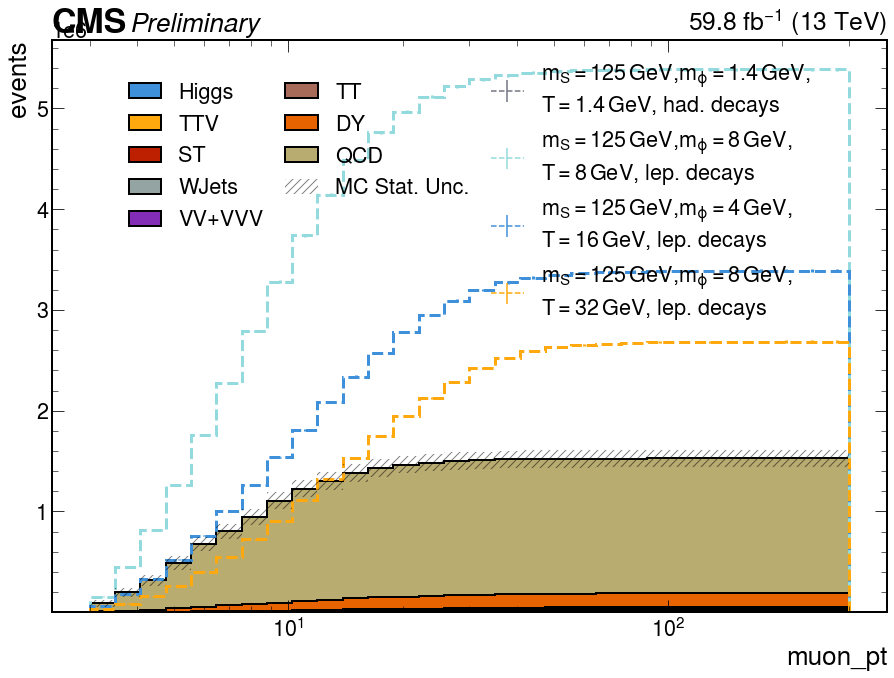

SR_low_temp_loose

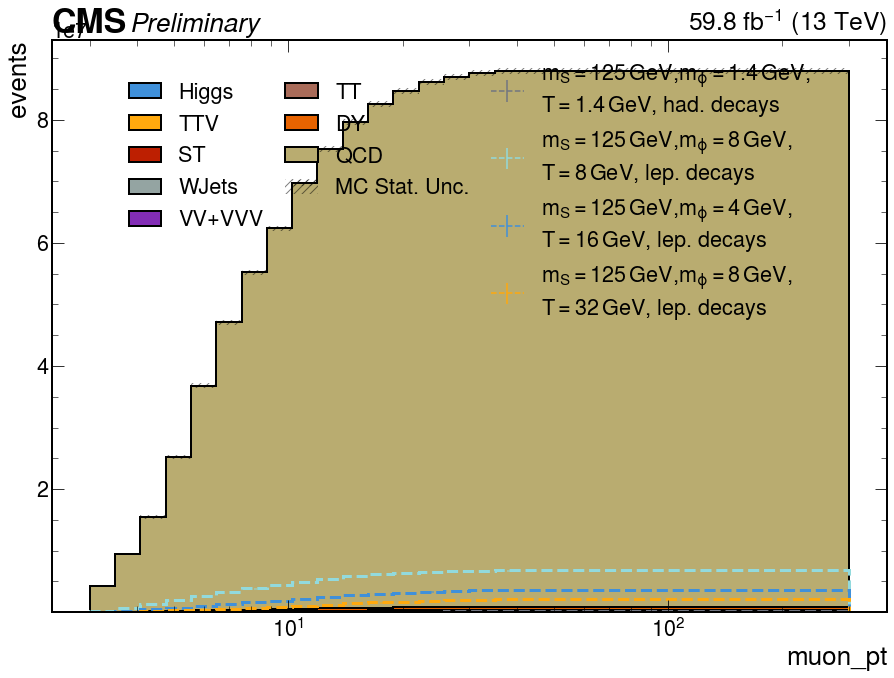

SR_low_temp_tight

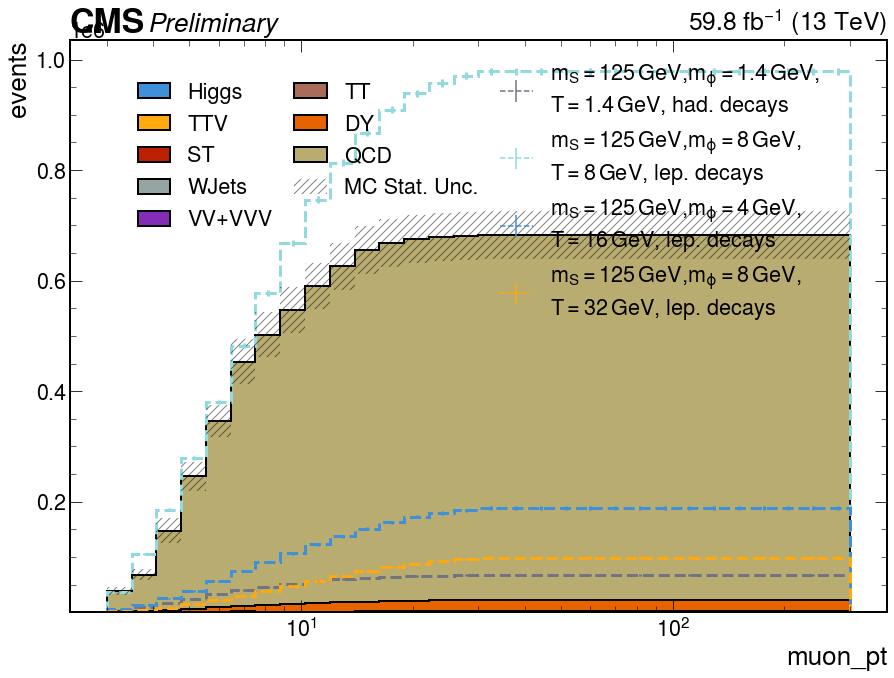

In [49]:
for region in [
    "CR_prompt",
    "CR_cb",
    "SR_high_temp_loose",
    "SR_high_temp_tight",
    "SR_low_temp_loose",
    "SR_low_temp_tight",
]:
    print(region)
    mc_processes = [
        ("Higgs_2018", "Higgs"),
        ("TTV_2018", "TTV"),
        ("ST_NLO_2018", "ST"),
        ("WJets_2018", "WJets"),
        ("VV+VVV_2018", "VV+VVV"),
        ("TT_powheg_2018", "TT"),
        ("DY_2018", "DY"),
        ("QCD_Pt_MuEnrichedPt5_2018", "QCD"),
    ]

    signal_processes = [
        "GluGluToSUEP_mS125.000_mPhi1.400_T1.400_modehadronic_13TeV_2018",
        "GluGluToSUEP_mS125.000_mPhi8.000_T8.000_modeleptonic_13TeV_2018",
        "GluGluToSUEP_mS125.000_mPhi4.000_T16.000_modeleptonic_13TeV_2018",
        "GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018",
    ]
    signal_labels = [
        r"$m_S=125\,$GeV,$m_\phi=1.4\,$GeV," + "\n" + r"$T=1.4\,$GeV, had. decays",
        r"$m_S=125\,$GeV,$m_\phi=8\,$GeV," + "\n" + r"$T=8\,$GeV, lep. decays",
        r"$m_S=125\,$GeV,$m_\phi=4\,$GeV," + "\n" + r"$T=16\,$GeV, lep. decays",
        r"$m_S=125\,$GeV,$m_\phi=8\,$GeV," + "\n" + r"$T=32\,$GeV, lep. decays",
    ]

    hists_mc = []
    hist_bkg_total = (
        plots_cdfs["GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018"][
            region
        ]
        .copy()
        .reset()
    )

    for process, label in mc_processes:
        h_mc = plots_cdfs[process][region]
        hists_mc.append(h_mc)
        hist_bkg_total += h_mc.copy()

    hists_signal = []
    for process in signal_processes:
        h_signal = plots_cdfs[process][region]
        hists_signal.append(h_signal)

    fig, ax1 = plt.subplots(figsize=(13, 10))

    hep.histplot(
        hists_mc,
        yerr=[np.sqrt(h.variances()) for h in hists_mc],
        stack=True,
        label=[p[1] for p in mc_processes],
        histtype="fill",
        ec="black",
        lw=2,
        ax=ax1,
    )

    x_hatch = np.vstack(
        (hist_bkg_total.axes[0].edges[:-1], hist_bkg_total.axes[0].edges[1:])
    ).reshape((-1,), order="F")
    y_hatch1 = np.vstack((hist_bkg_total.values(), hist_bkg_total.values())).reshape(
        (-1,), order="F"
    )
    y_hatch1_unc = np.vstack(
        (np.sqrt(hist_bkg_total.variances()), np.sqrt(hist_bkg_total.variances()))
    ).reshape((-1,), order="F")
    ax1.fill_between(
        x=x_hatch,
        y1=y_hatch1 - y_hatch1_unc,  # type: ignore[assign]
        y2=y_hatch1 + y_hatch1_unc,  # type: ignore[assign]
        label="MC Stat. Unc.",
        step="pre",
        facecolor="none",
        edgecolor=(0, 0, 0, 0.5),
        linewidth=0,
        hatch="///",
        zorder=2,
    )
    hep.histplot(
        hists_signal,
        yerr=[np.sqrt(h.variances()) for h in hists_signal],
        label=[s for s in signal_labels],
        lw=3,
        ls="--",
        ax=ax1,
    )

    hep.cms.label(llabel="Preliminary", data=True, lumi=59.8, ax=ax1)

    # plt.ylim(1e0, 1e10)
    plt.xscale("log")
    # plt.yscale("log")
    plt.legend(ncol=3, loc="upper center", columnspacing=1)
    plt.ylabel("events")
    plt.tight_layout()
    plt.show()